Device  : cuda
Seeds   : [42, 123, 256, 999, 2024]
Channels: ['PSG_F3:A2', 'PSG_C3:A2', 'PSG_EOG1:A2']

Loading 96 subjects into RAM... Done ✅
Split loaded ✅ → Train:76  Test:20
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Train samples: 71347  |  Test samples: 19763

  SEED 42
  Parameters: 372,165
  Training 30 epochs...
  Ep[01/30] Loss:0.811 TrAcc:0.727 ValAcc:0.776 F1(M):0.714 κ:0.688 ← BEST
  Ep[02/30] Loss:0.704 TrAcc:0.770 ValAcc:0.772 F1(M):0.721 κ:0.682 ← BEST
  Ep[03/30] Loss:0.674 TrAcc:0.779 ValAcc:0.785 F1(M):0.724 κ:0.698 ← BEST
  Ep[04/30] Loss:0.657 TrAcc:0.783 ValAcc:0.782 F1(M):0.712 κ:0.693
  Ep[05/30] Loss:0.639 TrAcc:0.786 ValAcc:0.771 F1(M):0.702 κ:0.678
  Ep[06/30] Loss:0.628 TrAcc:0.791 ValAcc:0.759 F1(M):0.702 κ:0.661
  Ep[07/30] Loss:0.620 TrAcc:0.792 ValAcc:0.786 F1(M):0.73

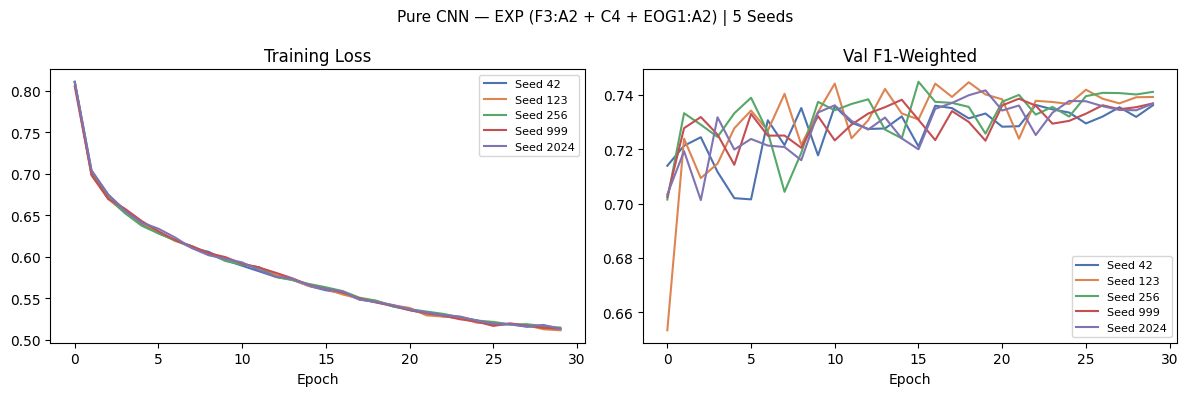

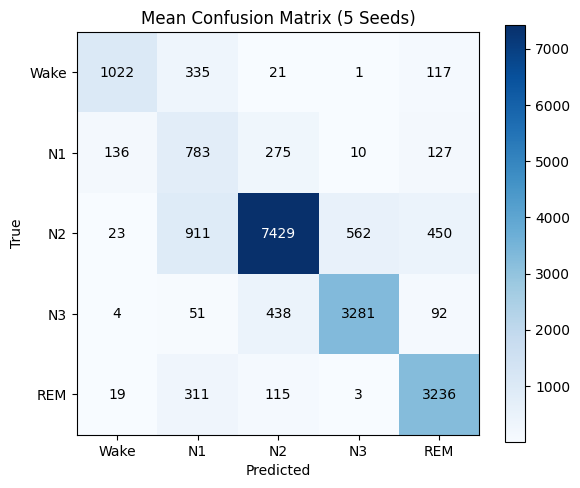

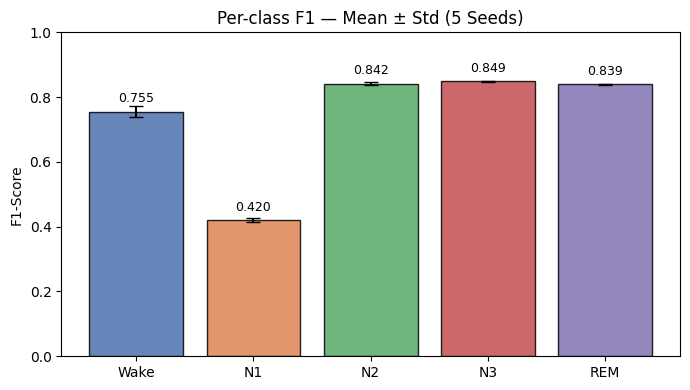


Plots saved → D:\22\AA\evaluation\CNN


In [3]:
# ============================================================
# Pure CNN — EXP-4 (2EEG + EOG2) | 5 Seeds — Fixed Split
# ============================================================
import os, csv, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, cohen_kappa_score)
from collections import Counter
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
SAVE_DIR   = r"D:\22\AA\evaluation\CNN"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS     = 30
BATCH_SIZE = 128
LR         = 1e-3
SEEDS      = [42, 123, 256, 999, 2024]

CH_LIST = [
    "PSG_F3:A2",
    "PSG_C3:A2",
    "PSG_EOG1:A2"
]
IN_CH = 3
EEG_INDEX = {
    "PSG_F3:A2":   ("eeg", 0),
    "PSG_C3:A2":     ("eeg", 1),
    "PSG_EOG1:A2": ("eog", 0),
}
LABEL_MAP = {0:"Wake", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

print(f"Device  : {DEVICE}")
print(f"Seeds   : {SEEDS}")
print(f"Channels: {CH_LIST}")

# ============================================================
# PRELOAD
# ============================================================
all_subjects = sorted([
    f.replace(".npz","") for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])
print(f"\nLoading {len(all_subjects)} subjects into RAM...", end=" ")
npz_cache = {}
for sub in all_subjects:
    d = np.load(os.path.join(SAVE_PATH, f"{sub}.npz"))
    npz_cache[sub] = {k: d[k] for k in ["eeg","eog","labels"]}
print("Done ✅")

# ============================================================
# FIXED SPLIT
# ============================================================
_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded ✅ → Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n          = int(0.8 * len(_subs))
    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]
    np.save(_train_path, np.array(TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created ✅ → Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

print(f"TEST_SUBS: {TEST_SUBS}")

# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def build_xy(subject_list):
    X_all, y_all = [], []
    for sub in subject_list:
        d = npz_cache[sub]
        channels = []
        for ch in CH_LIST:
            arr, idx = EEG_INDEX[ch]
            channels.append(d[arr][:, idx, :])
        X_all.append(np.stack(channels, axis=1).astype(np.float32))
        y_all.append(d["labels"])
    return (np.concatenate(X_all, 0),
            np.concatenate(y_all, 0).astype(np.int64))


class SleepDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def class_weights(y):
    c = Counter(y.tolist())
    w = [len(y) / (5 * c.get(i,1)) for i in range(5)]
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)


def bar_str(val, width=16):
    filled = int(round(val * width))
    return "█" * filled + "░" * (width - filled)

# ============================================================
# MODEL — Pure CNN
# ============================================================
class SleepCNN(nn.Module):
    def __init__(self, in_ch=3, n_class=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 64,  kernel_size=50, stride=5, padding=25),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(4), nn.Dropout(0.3),

            nn.Conv1d(64,  128, kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3),

            nn.Conv1d(128, 256, kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_class),
        )

    def forward(self, x):
        return self.fc(self.net(x))

# ============================================================
# TRAIN / EVAL
# ============================================================
def train_epoch(model, loader, opt, crit):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out  = model(X)
        loss = crit(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_sum += loss.item()
        correct  += (out.argmax(1) == y).sum().item()
        total    += len(y)
    return loss_sum / len(loader), correct / total


def eval_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.extend(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    preds = np.array(preds)
    trues = np.array(trues)
    acc   = accuracy_score(trues, preds)
    f1_w  = f1_score(trues, preds, average="weighted", zero_division=0)
    f1_m  = f1_score(trues, preds, average="macro",    zero_division=0)
    f1_pc = f1_score(trues, preds, average=None,       zero_division=0, labels=[0,1,2,3,4])
    kappa = cohen_kappa_score(trues, preds)
    cm    = confusion_matrix(trues, preds, labels=[0,1,2,3,4])
    return acc, f1_w, f1_m, f1_pc, kappa, cm

# ============================================================
# DATA — একবারই build
# ============================================================
X_tr, y_tr = build_xy(TRAIN_SUBS)
X_te, y_te = build_xy(TEST_SUBS)
print(f"\nTrain samples: {len(y_tr)}  |  Test samples: {len(y_te)}")

te_dl = DataLoader(SleepDS(X_te, y_te), BATCH_SIZE,
                   shuffle=False, pin_memory=True, num_workers=0)

# ============================================================
# RUN 5 SEEDS
# ============================================================
csv_path = os.path.join(SAVE_DIR, "results_all_seeds.csv")
fields   = ["seed","acc","f1_weighted","f1_macro","kappa",
            "f1_Wake","f1_N1","f1_N2","f1_N3","f1_REM"]
with open(csv_path, "w", newline="") as f:
    csv.DictWriter(f, fields).writeheader()

# Per-epoch log (for plotting loss/F1 curves later without rerunning)
epoch_csv_path = os.path.join(SAVE_DIR, "all_seeds_epoch_log.csv")
epoch_fields = ["seed", "epoch", "tr_loss", "tr_acc", "val_acc", "val_f1"]
with open(epoch_csv_path, "w", newline="") as f:
    csv.writer(f).writerow(epoch_fields)

all_results = []
all_cms     = []
history_all = {}

for seed in SEEDS:
    set_seed(seed)

    print(f"\n{'='*60}")
    print(f"  SEED {seed}")
    print(f"{'='*60}")

    tr_dl = DataLoader(SleepDS(X_tr, y_tr), BATCH_SIZE,
                       shuffle=True, pin_memory=True, num_workers=0)

    model = SleepCNN(in_ch=IN_CH).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=class_weights(y_tr))
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {n_params:,}")
    print(f"  Training {EPOCHS} epochs...")

    best_f1, best_state = 0.0, None
    hist = {"loss":[], "tr_acc":[], "val_acc":[], "f1":[]}

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, tr_dl, opt, crit)
        sched.step()
        acc, f1_w, f1_m, f1_pc, kappa, _ = eval_model(model, te_dl)

        hist["loss"].append(tr_loss)
        hist["tr_acc"].append(tr_acc)
        hist["val_acc"].append(acc)
        hist["f1"].append(f1_m)

        tag = ""
        if f1_m > best_f1:
            best_f1    = f1_m
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            tag        = " ← BEST"

        print(f"  Ep[{ep:02d}/{EPOCHS}] "
              f"Loss:{tr_loss:.3f} "
              f"TrAcc:{tr_acc:.3f} "
              f"ValAcc:{acc:.3f} "
              f"F1(M):{f1_m:.3f} "
              f"κ:{kappa:.3f}{tag}")

        if ep % 10 == 0:
            print(f"    Per-class F1:")
            for i, name in LABEL_MAP.items():
                print(f"      {name}: {f1_pc[i]:.4f}")

        with open(epoch_csv_path, "a", newline="") as f:
            csv.writer(f).writerow([seed, ep, f"{tr_loss:.4f}", f"{tr_acc:.4f}",
                                     f"{acc:.4f}", f"{f1_m:.4f}"])

    history_all[seed] = hist

    model.load_state_dict(best_state)
    model.to(DEVICE)
    acc, f1_w, f1_m, f1_pc, kappa, cm = eval_model(model, te_dl)
    all_cms.append(cm)

    print(f"\n  *** FINAL: Acc={acc*100:.2f}% F1={f1_w:.4f} κ={kappa:.4f} ***")
    print(f"\n  FINAL EVALUATION REPORT — Pure CNN  [Seed {seed}]")
    print(f"  {'='*51}")
    print(f"  Overall Accuracy   : {acc*100:.2f}%")
    print(f"  Macro F1-Score     : {f1_m:.4f}")
    print(f"  Weighted F1-Score  : {f1_w:.4f}")
    print(f"  Cohen's Kappa (κ)  : {kappa:.4f}")
    print(f"  {'-'*51}")
    print(f"  Per-class F1:")
    for i, name in LABEL_MAP.items():
        print(f"    {name:<5}: {f1_pc[i]:.4f}  {bar_str(f1_pc[i])}")
    print(f"  {'='*51}")

    row = {
        "seed": seed, "acc": round(acc,4),
        "f1_weighted": round(f1_w,4), "f1_macro": round(f1_m,4),
        "kappa": round(kappa,4),
        "f1_Wake": round(f1_pc[0],4), "f1_N1": round(f1_pc[1],4),
        "f1_N2":  round(f1_pc[2],4), "f1_N3": round(f1_pc[3],4),
        "f1_REM": round(f1_pc[4],4),
    }
    with open(csv_path, "a", newline="") as f:
        csv.DictWriter(f, fields).writerow(row)
    all_results.append(row)
    torch.save(best_state, os.path.join(SAVE_DIR, f"model_seed{seed}.pt"))

# ============================================================
# SUMMARY
# ============================================================
accs   = [r["acc"]         for r in all_results]
f1ws   = [r["f1_weighted"] for r in all_results]
f1ms   = [r["f1_macro"]    for r in all_results]
kappas = [r["kappa"]       for r in all_results]

print(f"\n{'='*60}")
print(f"  5-SEED SUMMARY — Pure CNN")
print(f"{'='*60}")
print(f"  {'Seed':<8} {'Acc':>7} {'F1-W':>7} {'F1-M':>7} {'κ':>7}")
print(f"  {'-'*40}")
for r in all_results:
    print(f"  {r['seed']:<8} {r['acc']:>7.4f} {r['f1_weighted']:>7.4f} "
          f"{r['f1_macro']:>7.4f} {r['kappa']:>7.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<8} {np.mean(accs):>7.4f} {np.mean(f1ws):>7.4f} "
      f"{np.mean(f1ms):>7.4f} {np.mean(kappas):>7.4f}")
print(f"  {'Std':<8} {np.std(accs):>7.4f} {np.std(f1ws):>7.4f} "
      f"{np.std(f1ms):>7.4f} {np.std(kappas):>7.4f}")
print(f"\n  Results → {csv_path}")

with open(csv_path, "a", newline="") as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed":"mean","acc":round(np.mean(accs),4),
                "f1_weighted":round(np.mean(f1ws),4),"f1_macro":round(np.mean(f1ms),4),
                "kappa":round(np.mean(kappas),4),
                "f1_Wake":round(np.mean([r["f1_Wake"] for r in all_results]),4),
                "f1_N1": round(np.mean([r["f1_N1"]  for r in all_results]),4),
                "f1_N2": round(np.mean([r["f1_N2"]  for r in all_results]),4),
                "f1_N3": round(np.mean([r["f1_N3"]  for r in all_results]),4),
                "f1_REM":round(np.mean([r["f1_REM"] for r in all_results]),4)})
    w.writerow({"seed":"std","acc":round(np.std(accs),4),
                "f1_weighted":round(np.std(f1ws),4),"f1_macro":round(np.std(f1ms),4),
                "kappa":round(np.std(kappas),4),
                "f1_Wake":round(np.std([r["f1_Wake"] for r in all_results]),4),
                "f1_N1": round(np.std([r["f1_N1"]  for r in all_results]),4),
                "f1_N2": round(np.std([r["f1_N2"]  for r in all_results]),4),
                "f1_N3": round(np.std([r["f1_N3"]  for r in all_results]),4),
                "f1_REM":round(np.std([r["f1_REM"] for r in all_results]),4)})

# ============================================================
# PLOTS
# ============================================================
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, seed in enumerate(SEEDS):
    h = history_all[seed]
    axes[0].plot(h["loss"], label=f"Seed {seed}", color=colors[i])
    axes[1].plot(h["f1"],   label=f"Seed {seed}", color=colors[i])
axes[0].set_title("Training Loss");   axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Val F1-Weighted"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.suptitle(
    "Pure CNN — EXP (F3:A2 + C4 + EOG1:A2) | 5 Seeds",
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

mean_cm = np.mean(all_cms, axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(mean_cm, cmap="Blues")
lbl = ["Wake","N1","N2","N3","REM"]
ax.set_xticks(range(5)); ax.set_xticklabels(lbl)
ax.set_yticks(range(5)); ax.set_yticklabels(lbl)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Mean Confusion Matrix (5 Seeds)")
for i in range(5):
    for j in range(5):
        ax.text(j, i, mean_cm[i,j], ha="center", va="center",
                color="white" if mean_cm[i,j] > mean_cm.max()*0.5 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

stages   = ["Wake","N1","N2","N3","REM"]
keys     = ["f1_Wake","f1_N1","f1_N2","f1_N3","f1_REM"]
means_pc = [np.mean([r[k] for r in all_results]) for k in keys]
stds_pc  = [np.std( [r[k] for r in all_results]) for k in keys]
fig, ax  = plt.subplots(figsize=(7,4))
bars = ax.bar(stages, means_pc, yerr=stds_pc, capsize=5,
              color=colors, edgecolor="black", alpha=0.85)
ax.set_ylim(0, 1.0); ax.set_ylabel("F1-Score")
ax.set_title("Per-class F1 — Mean ± Std (5 Seeds)")
for bar, m in zip(bars, means_pc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{m:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "perclass_f1.png"), dpi=150)
plt.show()

print(f"\nPlots saved → {SAVE_DIR}")

Device  : cuda
Seeds   : [42, 123, 256, 999, 2024]
Channels: ['PSG_F3:A2', 'PSG_C3:A2', 'PSG_EOG1:A2']

Loading 96 subjects into RAM... Done ✅

Fixed split loaded ✅ → Train:76 Test:20
TEST subjects: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Creating subject-wise train/validation split...
Train subjects      : 61
Validation subjects : 15
Test subjects       : 20

Train samples: 57957
Validation samples: 13390
Test samples: 19763

  SEED 42
Parameters: 372,165
Training 30 epochs...
  Ep[01/30] Loss:0.820 TrAcc:0.729 ValAcc:0.752 ValF1:0.670 κ:0.656 ← BEST VAL
  Ep[02/30] Loss:0.707 TrAcc:0.774 ValAcc:0.792 ValF1:0.703 κ:0.703 ← BEST VAL
  Ep[03/30] Loss:0.675 TrAcc:0.781 ValAcc:0.794 ValF1:0.702 κ:0.705
  Ep[04/30] Loss:0.660 TrAcc:0.786 ValAcc:0.816 ValF1:0.725 κ:0.732 ← BEST VAL
  Ep[05/30] Loss:0.647 TrAcc:0

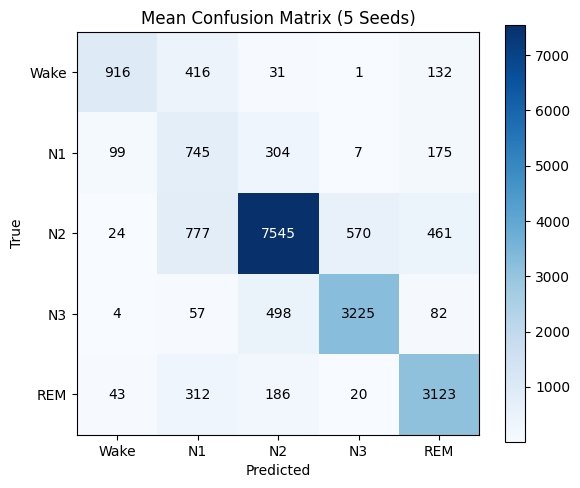

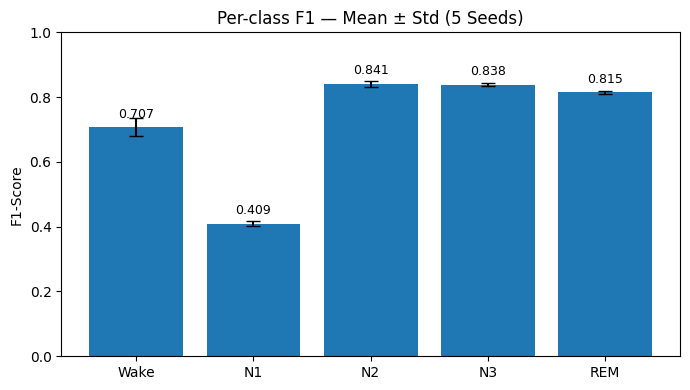

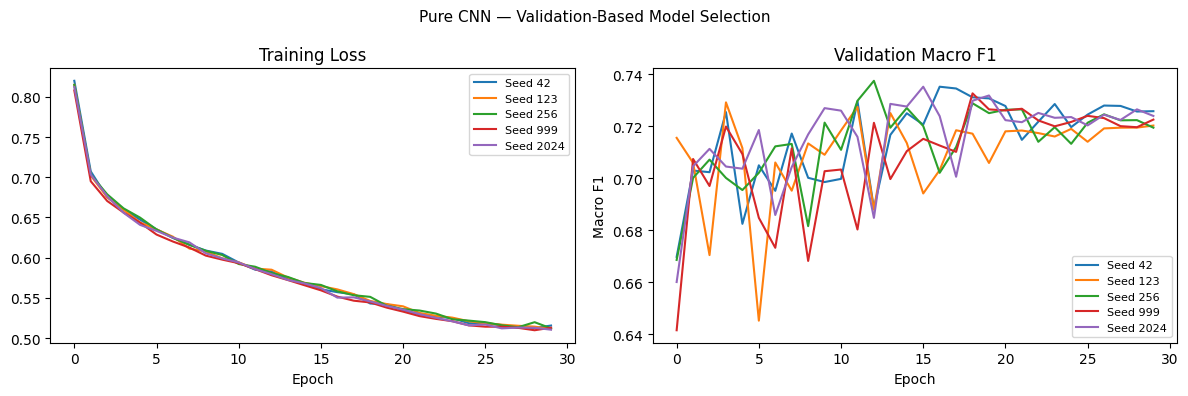


Plots and models saved → D:\22\ii\AA\evaluation\CNN

✅ Test set was NOT used for checkpoint selection.
✅ Test set was evaluated only after the best validation checkpoint was selected.


In [1]:
# ============================================================
# Pure CNN — EXP-4 (2EEG + EOG1) | 5 Seeds
# FIXED: Subject-wise Train / Validation / Test
# NO TEST-SET MODEL SELECTION
# NO CSV
# ============================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)
from collections import Counter

import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_Final"
SAVE_DIR  = r"D:\22\ii\AA\evaluation\CNN"

os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS     = 30
BATCH_SIZE = 128
LR         = 1e-3

SEEDS = [42, 123, 256, 999, 2024]

# ------------------------------------------------------------
# Existing fixed TEST split
# ------------------------------------------------------------

VAL_RATIO = 0.20

CH_LIST = [
    "PSG_F3:A2",
    "PSG_C3:A2",
    "PSG_EOG1:A2"
]

IN_CH = 3

EEG_INDEX = {
    "PSG_F3:A2":   ("eeg", 0),
    "PSG_C3:A2":   ("eeg", 1),
    "PSG_EOG1:A2": ("eog", 0),
}

LABEL_MAP = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    4: "REM"
}


print(f"Device  : {DEVICE}")
print(f"Seeds   : {SEEDS}")
print(f"Channels: {CH_LIST}")


# ============================================================
# PRELOAD
# ============================================================

all_subjects = sorted([
    f.replace(".npz", "")
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])

print(f"\nLoading {len(all_subjects)} subjects into RAM...", end=" ")

npz_cache = {}

for sub in all_subjects:
    d = np.load(
        os.path.join(SAVE_PATH, f"{sub}.npz")
    )

    npz_cache[sub] = {
        k: d[k]
        for k in ["eeg", "eog", "labels"]
    }

print("Done ✅")


# ============================================================
# FIXED TEST SPLIT
# ============================================================

_train_path = os.path.join(
    SAVE_PATH, "_train_subs.npy"
)

_test_path = os.path.join(
    SAVE_PATH, "_test_subs.npy"
)

if (
    os.path.exists(_train_path)
    and os.path.exists(_test_path)
):

    TRAIN_SUBS = np.load(
        _train_path,
        allow_pickle=True
    ).tolist()

    TEST_SUBS = np.load(
        _test_path,
        allow_pickle=True
    ).tolist()

    print(
        f"\nFixed split loaded ✅ "
        f"→ Train:{len(TRAIN_SUBS)} "
        f"Test:{len(TEST_SUBS)}"
    )

else:

    _subs = all_subjects.copy()

    random.seed(42)
    random.shuffle(_subs)

    n = int(0.8 * len(_subs))

    TRAIN_SUBS = _subs[:n]
    TEST_SUBS  = _subs[n:]

    np.save(
        _train_path,
        np.array(TRAIN_SUBS)
    )

    np.save(
        _test_path,
        np.array(TEST_SUBS)
    )

    print(
        f"\nFixed split created ✅ "
        f"→ Train:{len(TRAIN_SUBS)} "
        f"Test:{len(TEST_SUBS)}"
    )


print(f"TEST subjects: {TEST_SUBS}")


# ============================================================
# SUBJECT-WISE VALIDATION SPLIT
# ============================================================

# IMPORTANT:
# Validation subjects are taken ONLY from TRAIN_SUBS.
# Test subjects are NEVER used for model selection.

def make_train_val_split(train_subjects, seed):

    subjects = train_subjects.copy()

    rng = random.Random(seed)
    rng.shuffle(subjects)

    n_val = max(
        1,
        int(len(subjects) * VAL_RATIO)
    )

    val_subjects = subjects[:n_val]
    train_subjects_new = subjects[n_val:]

    return train_subjects_new, val_subjects


# ============================================================
# HELPERS
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_xy(subject_list):

    X_all = []
    y_all = []

    for sub in subject_list:

        d = npz_cache[sub]

        channels = []

        for ch in CH_LIST:

            arr, idx = EEG_INDEX[ch]

            channels.append(
                d[arr][:, idx, :]
            )

        X_all.append(
            np.stack(
                channels,
                axis=1
            ).astype(np.float32)
        )

        y_all.append(
            d["labels"]
        )

    return (
        np.concatenate(X_all, axis=0),
        np.concatenate(y_all, axis=0).astype(np.int64)
    )


class SleepDS(Dataset):

    def __init__(self, X, y):

        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):

        return len(self.y)

    def __getitem__(self, i):

        return self.X[i], self.y[i]


def class_weights(y):

    c = Counter(y.tolist())

    w = [
        len(y) / (5 * c.get(i, 1))
        for i in range(5)
    ]

    return torch.tensor(
        w,
        dtype=torch.float32
    ).to(DEVICE)


def bar_str(val, width=16):

    filled = int(
        round(val * width)
    )

    return (
        "█" * filled
        + "░" * (width - filled)
    )


# ============================================================
# MODEL — PURE CNN
# ============================================================

class SleepCNN(nn.Module):

    def __init__(
        self,
        in_ch=3,
        n_class=5
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv1d(
                in_ch,
                64,
                kernel_size=50,
                stride=5,
                padding=25
            ),

            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),
            nn.Dropout(0.3),

            nn.Conv1d(
                64,
                128,
                kernel_size=8,
                stride=1,
                padding=4
            ),

            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            nn.Conv1d(
                128,
                256,
                kernel_size=8,
                stride=1,
                padding=4
            ),

            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                128,
                n_class
            )
        )


    def forward(self, x):

        return self.fc(
            self.net(x)
        )


# ============================================================
# TRAIN
# ============================================================

def train_epoch(
    model,
    loader,
    opt,
    crit
):

    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for X, y in loader:

        X = X.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        opt.zero_grad()

        out = model(X)

        loss = crit(
            out,
            y
        )

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        opt.step()

        loss_sum += loss.item()

        correct += (
            out.argmax(1) == y
        ).sum().item()

        total += len(y)

    return (
        loss_sum / len(loader),
        correct / total
    )


# ============================================================
# EVALUATION
# ============================================================

def eval_model(
    model,
    loader
):

    model.eval()

    preds = []
    trues = []

    with torch.no_grad():

        for X, y in loader:

            out = model(
                X.to(DEVICE)
            )

            preds.extend(
                out.argmax(1)
                .cpu()
                .numpy()
            )

            trues.extend(
                y.numpy()
            )

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    acc = accuracy_score(
        trues,
        preds
    )

    f1_w = f1_score(
        trues,
        preds,
        average="weighted",
        zero_division=0
    )

    f1_m = f1_score(
        trues,
        preds,
        average="macro",
        zero_division=0
    )

    f1_pc = f1_score(
        trues,
        preds,
        average=None,
        labels=[0,1,2,3,4],
        zero_division=0
    )

    kappa = cohen_kappa_score(
        trues,
        preds
    )

    cm = confusion_matrix(
        trues,
        preds,
        labels=[0,1,2,3,4]
    )

    return (
        acc,
        f1_w,
        f1_m,
        f1_pc,
        kappa,
        cm
    )


# ============================================================
# BUILD TRAIN / VALIDATION / TEST
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
# Test subjects are NEVER included here.
# ------------------------------------------------------------

print("\nCreating subject-wise train/validation split...")

# Use a fixed seed for the split so every model gets
# exactly the same train/validation subjects.
TRAIN_SUBS_FINAL, VAL_SUBS = make_train_val_split(
    TRAIN_SUBS,
    seed=42
)

print(
    f"Train subjects      : {len(TRAIN_SUBS_FINAL)}"
)

print(
    f"Validation subjects : {len(VAL_SUBS)}"
)

print(
    f"Test subjects       : {len(TEST_SUBS)}"
)


# ------------------------------------------------------------
# Build arrays
# ------------------------------------------------------------

X_tr, y_tr = build_xy(
    TRAIN_SUBS_FINAL
)

X_val, y_val = build_xy(
    VAL_SUBS
)

X_te, y_te = build_xy(
    TEST_SUBS
)

print(
    f"\nTrain samples: {len(y_tr)}"
)

print(
    f"Validation samples: {len(y_val)}"
)

print(
    f"Test samples: {len(y_te)}"
)


# ============================================================
# DATALOADERS
# ============================================================

tr_dl = DataLoader(
    SleepDS(X_tr, y_tr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=0
)

val_dl = DataLoader(
    SleepDS(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0
)

te_dl = DataLoader(
    SleepDS(X_te, y_te),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=0
)


# ============================================================
# RUN 5 SEEDS
# ============================================================

all_results = []
all_cms = []

history_all = {}


for seed in SEEDS:

    set_seed(seed)

    print(
        f"\n{'='*65}"
    )

    print(
        f"  SEED {seed}"
    )

    print(
        f"{'='*65}"
    )


    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = SleepCNN(
        in_ch=IN_CH
    ).to(DEVICE)


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    crit = nn.CrossEntropyLoss(
        weight=class_weights(y_tr)
    )


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    opt = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )


    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=EPOCHS
    )


    n_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"Parameters: {n_params:,}"
    )

    print(
        f"Training {EPOCHS} epochs..."
    )


    # ========================================================
    # BEST MODEL BASED ONLY ON VALIDATION F1
    # ========================================================

    best_val_f1 = -1.0
    best_state = None

    hist = {
        "loss": [],
        "tr_acc": [],
        "val_acc": [],
        "val_f1": []
    }


    for ep in range(
        1,
        EPOCHS + 1
    ):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        tr_loss, tr_acc = train_epoch(
            model,
            tr_dl,
            opt,
            crit
        )

        sched.step()


        # ----------------------------------------------------
        # VALIDATION ONLY
        #
        # TEST SET IS NOT TOUCHED HERE
        # ----------------------------------------------------

        (
            val_acc,
            val_f1_w,
            val_f1_m,
            val_f1_pc,
            val_kappa,
            _
        ) = eval_model(
            model,
            val_dl
        )


        hist["loss"].append(
            tr_loss
        )

        hist["tr_acc"].append(
            tr_acc
        )

        hist["val_acc"].append(
            val_acc
        )

        hist["val_f1"].append(
            val_f1_m
        )


        # ----------------------------------------------------
        # BEST CHECKPOINT
        #
        # VALIDATION F1 ONLY
        # ----------------------------------------------------

        tag = ""

        if val_f1_m > best_val_f1:

            best_val_f1 = val_f1_m

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            tag = " ← BEST VAL"


        print(
            f"  Ep[{ep:02d}/{EPOCHS}] "
            f"Loss:{tr_loss:.3f} "
            f"TrAcc:{tr_acc:.3f} "
            f"ValAcc:{val_acc:.3f} "
            f"ValF1:{val_f1_m:.3f} "
            f"κ:{val_kappa:.3f}"
            f"{tag}"
        )


    # ========================================================
    # RESTORE BEST VALIDATION CHECKPOINT
    # ========================================================

    model.load_state_dict(
        best_state
    )

    model.to(DEVICE)


    # ========================================================
    # FINAL TEST
    #
    # THIS IS THE FIRST TIME TEST SET IS USED
    # FOR THIS SEED.
    # ========================================================

    (
        test_acc,
        test_f1_w,
        test_f1_m,
        test_f1_pc,
        test_kappa,
        test_cm
    ) = eval_model(
        model,
        te_dl
    )


    all_cms.append(
        test_cm
    )

    history_all[seed] = hist


    # ========================================================
    # FINAL REPORT
    # ========================================================

    print(
        f"\n  *** FINAL TEST RESULT ***"
    )

    print(
        f"  Accuracy       : "
        f"{test_acc*100:.2f}%"
    )

    print(
        f"  Macro F1       : "
        f"{test_f1_m:.4f}"
    )

    print(
        f"  Weighted F1    : "
        f"{test_f1_w:.4f}"
    )

    print(
        f"  Cohen's Kappa  : "
        f"{test_kappa:.4f}"
    )

    print(
        f"  Per-class F1:"
    )

    for i, name in LABEL_MAP.items():

        print(
            f"    {name:<5}: "
            f"{test_f1_pc[i]:.4f} "
            f"{bar_str(test_f1_pc[i])}"
        )


    # ========================================================
    # STORE RESULT IN MEMORY ONLY
    # ========================================================

    row = {

        "seed": seed,

        "acc": test_acc,

        "f1_weighted": test_f1_w,

        "f1_macro": test_f1_m,

        "kappa": test_kappa,

        "f1_Wake": test_f1_pc[0],

        "f1_N1": test_f1_pc[1],

        "f1_N2": test_f1_pc[2],

        "f1_N3": test_f1_pc[3],

        "f1_REM": test_f1_pc[4]
    }

    all_results.append(
        row
    )


    # --------------------------------------------------------
    # SAVE MODEL
    # --------------------------------------------------------

    torch.save(
        best_state,
        os.path.join(
            SAVE_DIR,
            f"model_seed{seed}_VAL_SELECTED.pt"
        )
    )


# ============================================================
# SUMMARY
# ============================================================

accs = [
    r["acc"]
    for r in all_results
]

f1ws = [
    r["f1_weighted"]
    for r in all_results
]

f1ms = [
    r["f1_macro"]
    for r in all_results
]

kappas = [
    r["kappa"]
    for r in all_results
]


print(
    f"\n{'='*65}"
)

print(
    "  FINAL 5-SEED TEST SUMMARY"
)

print(
    f"{'='*65}"
)


print(
    f"{'Seed':<8}"
    f"{'Acc':>10}"
    f"{'F1-W':>10}"
    f"{'F1-M':>10}"
    f"{'Kappa':>10}"
)

print(
    "-" * 48
)


for r in all_results:

    print(
        f"{r['seed']:<8}"
        f"{r['acc']*100:>9.2f}%"
        f"{r['f1_weighted']:>10.4f}"
        f"{r['f1_macro']:>10.4f}"
        f"{r['kappa']:>10.4f}"
    )


print(
    "-" * 48
)

print(
    f"{'Mean':<8}"
    f"{np.mean(accs)*100:>9.2f}%"
    f"{np.mean(f1ws):>10.4f}"
    f"{np.mean(f1ms):>10.4f}"
    f"{np.mean(kappas):>10.4f}"
)

print(
    f"{'Std':<8}"
    f"{np.std(accs)*100:>9.2f}%"
    f"{np.std(f1ws):>10.4f}"
    f"{np.std(f1ms):>10.4f}"
    f"{np.std(kappas):>10.4f}"
)


# ============================================================
# MEAN CONFUSION MATRIX
# ============================================================

mean_cm = np.mean(
    all_cms,
    axis=0
).astype(int)


fig, ax = plt.subplots(
    figsize=(6, 5)
)

im = ax.imshow(
    mean_cm,
    cmap="Blues"
)

lbl = [
    "Wake",
    "N1",
    "N2",
    "N3",
    "REM"
]

ax.set_xticks(
    range(5)
)

ax.set_xticklabels(
    lbl
)

ax.set_yticks(
    range(5)
)

ax.set_yticklabels(
    lbl
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)

ax.set_title(
    "Mean Confusion Matrix (5 Seeds)"
)


for i in range(5):

    for j in range(5):

        ax.text(
            j,
            i,
            mean_cm[i, j],
            ha="center",
            va="center",
            color=(
                "white"
                if mean_cm[i, j]
                > mean_cm.max() * 0.5
                else "black"
            )
        )


plt.colorbar(
    im,
    ax=ax
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "confusion_matrix_VAL_SELECTED.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# PER-CLASS F1
# ============================================================

stages = [
    "Wake",
    "N1",
    "N2",
    "N3",
    "REM"
]

keys = [
    "f1_Wake",
    "f1_N1",
    "f1_N2",
    "f1_N3",
    "f1_REM"
]

means_pc = [
    np.mean([
        r[k]
        for r in all_results
    ])
    for k in keys
]

stds_pc = [
    np.std([
        r[k]
        for r in all_results
    ])
    for k in keys
]


fig, ax = plt.subplots(
    figsize=(7, 4)
)

bars = ax.bar(
    stages,
    means_pc,
    yerr=stds_pc,
    capsize=5
)

ax.set_ylim(
    0,
    1.0
)

ax.set_ylabel(
    "F1-Score"
)

ax.set_title(
    "Per-class F1 — Mean ± Std (5 Seeds)"
)


for bar, m in zip(
    bars,
    means_pc
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height()
        + 0.02,
        f"{m:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.tight_layout()

plt.savefig(
    os.path.join(
        SAVE_DIR,
        "perclass_f1_VAL_SELECTED.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)


for seed in SEEDS:

    h = history_all[seed]

    axes[0].plot(
        h["loss"],
        label=f"Seed {seed}"
    )

    axes[1].plot(
        h["val_f1"],
        label=f"Seed {seed}"
    )


axes[0].set_title(
    "Training Loss"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].legend(
    fontsize=8
)


axes[1].set_title(
    "Validation Macro F1"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "Macro F1"
)

axes[1].legend(
    fontsize=8
)


plt.suptitle(
    "Pure CNN — Validation-Based Model Selection",
    fontsize=11
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        SAVE_DIR,
        "training_curves_VAL_SELECTED.png"
    ),
    dpi=150
)

plt.show()


print(
    f"\nPlots and models saved → {SAVE_DIR}"
)

print(
    "\n✅ Test set was NOT used for checkpoint selection."
)

print(
    "✅ Test set was evaluated only after the best validation checkpoint was selected."
)

Device  : cuda
Seeds   : [42, 123, 256, 999, 2024]
Channels: ['PSG_F3:A2', 'PSG_C3:A2', 'PSG_EOG1:A2']

Loading 96 subjects into RAM... Done ✅
Split loaded ✅ → Train(full):76  Test:20
Train/Val split created ✅ (cached to D:\22\AA\preprocess\preprocessed_FFinal\_trainval_split.npz)
Final split ✅ → Train:65  Val:11  Test:20
VAL_SUBS : ['sub-010', 'sub-020', 'sub-031', 'sub-044', 'sub-050', 'sub-054', 'sub-060', 'sub-094', 'sub-097', 'sub-101', 'sub-108']
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019', 'sub-100']

Train samples: 61940  |  Val samples: 9407  |  Test samples: 19763

  SEED 42
  Parameters: 372,165
  Training 30 epochs...
  Ep[01/30] Loss:0.810 TrAcc:0.727 ValAcc:0.743 ValF1(M):0.662 Valκ:0.641 ← BEST
  Ep[02/30] Loss:0.701 TrAcc:0.770 ValAcc:0.766 ValF1(M):0.686 Valκ:0.676 ← BEST
  Ep[03/30] Loss:0.674 T

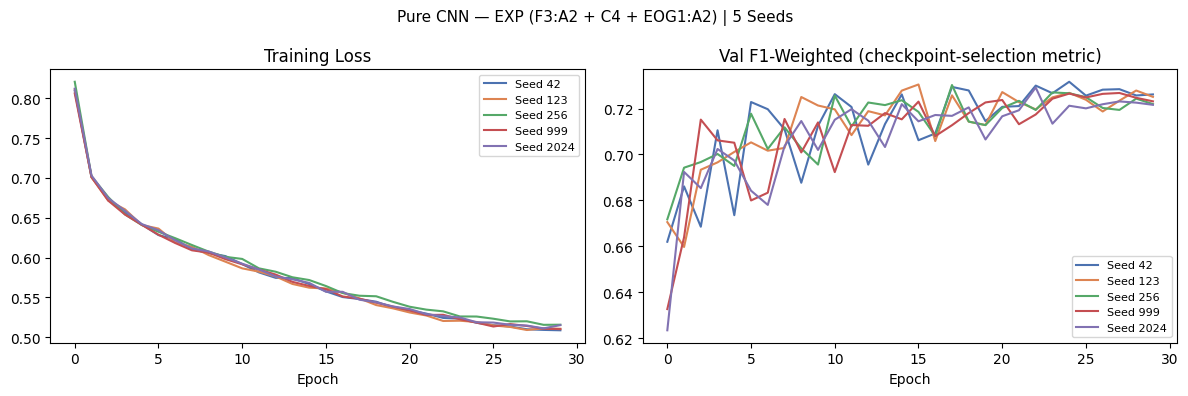

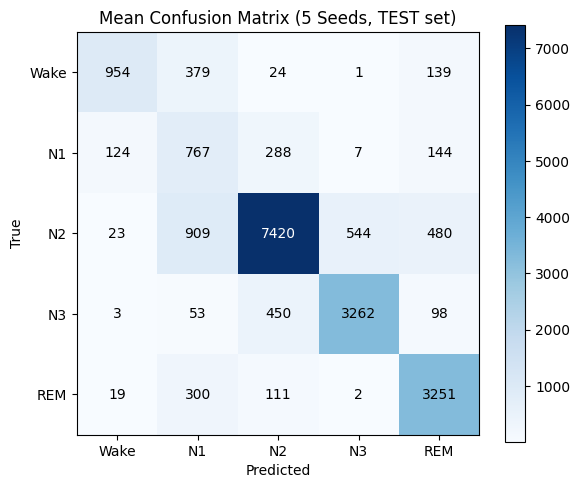

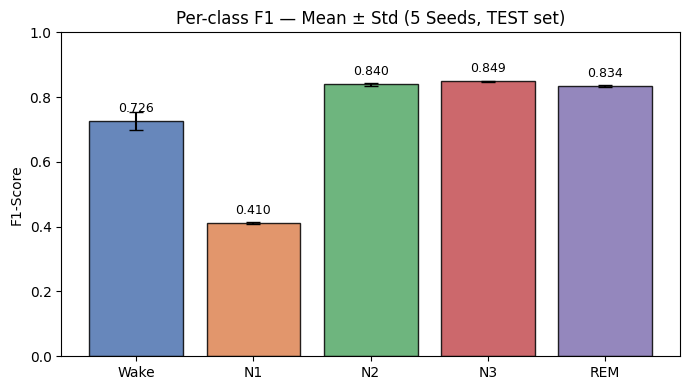


Plots saved → D:\22\ii\AA\evaluation\CNN_claude


In [2]:
# ============================================================
# Pure CNN — EXP-4 (2EEG + EOG2) | 5 Seeds — Fixed Split
# FIXED: No more test-set leakage in checkpoint selection.
#   - TRAIN_SUBS is now split subject-wise into TRAIN/VAL.
#   - Best checkpoint is selected using VAL F1 (not test F1).
#   - TEST_SUBS is touched exactly once, after training is done,
#     purely for final reporting.
#   - The train/val split is cached to disk (_trainval_split.npz)
#     so every other experiment (S1-S5, other architectures) can
#     reuse the EXACT SAME val set -> fair, comparable, reportable.
# ============================================================
import os, csv, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, cohen_kappa_score)
from collections import Counter
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
SAVE_DIR   = r"D:\22\ii\AA\evaluation\CNN_claude"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS     = 30
BATCH_SIZE = 128
LR         = 1e-3
SEEDS      = [42, 123, 256, 999, 2024]

# Fraction of TRAIN subjects held out as VAL (subject-wise, not epoch-wise)
# Reduced from 0.2 -> 0.15: with a small dataset (~92 usable subjects for
# Zmax+E4 experiments), every subject held out for val is training data lost.
# 0.15 still gives a reasonably stable val set for checkpoint selection
# while keeping more subjects in the actual gradient-training pool.
VAL_FRACTION = 0.15
# Seed used ONLY for the train/val subject split itself, so this
# split is identical and reproducible across every experiment/script
# that imports the same _trainval_split.npz — independent of the
# model-training SEEDS loop below.
SPLIT_SEED = 42

CH_LIST = [
    "PSG_F3:A2",
    "PSG_C3:A2",
    "PSG_EOG1:A2"
]
IN_CH = 3
EEG_INDEX = {
    "PSG_F3:A2":   ("eeg", 0),
    "PSG_C3:A2":     ("eeg", 1),
    "PSG_EOG1:A2": ("eog", 0),
}
LABEL_MAP = {0:"Wake", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}

print(f"Device  : {DEVICE}")
print(f"Seeds   : {SEEDS}")
print(f"Channels: {CH_LIST}")

# ============================================================
# PRELOAD
# ============================================================
all_subjects = sorted([
    f.replace(".npz","") for f in os.listdir(SAVE_PATH)
    if f.endswith(".npz") and not f.startswith("_")
])
print(f"\nLoading {len(all_subjects)} subjects into RAM...", end=" ")
npz_cache = {}
for sub in all_subjects:
    d = np.load(os.path.join(SAVE_PATH, f"{sub}.npz"))
    npz_cache[sub] = {k: d[k] for k in ["eeg","eog","labels"]}
print("Done ✅")

# ============================================================
# FIXED TRAIN/TEST SPLIT (unchanged — loaded from existing files)
# ============================================================
_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

if os.path.exists(_train_path) and os.path.exists(_test_path):
    FULL_TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
    TEST_SUBS       = np.load(_test_path,  allow_pickle=True).tolist()
    print(f"Split loaded ✅ → Train(full):{len(FULL_TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")
else:
    _subs = all_subjects.copy()
    random.seed(42)
    random.shuffle(_subs)
    n               = int(0.8 * len(_subs))
    FULL_TRAIN_SUBS = _subs[:n]
    TEST_SUBS       = _subs[n:]
    np.save(_train_path, np.array(FULL_TRAIN_SUBS))
    np.save(_test_path,  np.array(TEST_SUBS))
    print(f"Split created ✅ → Train(full):{len(FULL_TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")

# ============================================================
# NEW: TRAIN / VAL SPLIT (subject-wise, cached, reused everywhere)
#
# This is the actual fix. FULL_TRAIN_SUBS (the subjects previously
# used entirely for training) is now split into:
#   - TRAIN_SUBS : used for gradient updates only
#   - VAL_SUBS   : used ONLY for checkpoint selection (best_f1)
# TEST_SUBS remains completely untouched until the very end.
#
# The split is cached to _trainval_split.npz so that S1-S5 and any
# other architecture script loads the SAME val set -> apples-to-apples
# comparison across all your experiments.
# ============================================================
_trainval_path = os.path.join(SAVE_PATH, "_trainval_split.npz")

if os.path.exists(_trainval_path):
    _tv = np.load(_trainval_path, allow_pickle=True)
    TRAIN_SUBS = _tv["train_subs"].tolist()
    VAL_SUBS   = _tv["val_subs"].tolist()
    # Sanity check: cached split must match the current FULL_TRAIN_SUBS pool.
    # If preprocessing changed (subjects added/removed), rebuild instead
    # of silently using a stale/mismatched split.
    if set(TRAIN_SUBS + VAL_SUBS) != set(FULL_TRAIN_SUBS):
        print("  WARNING: cached train/val split doesn't match current "
              "train-subject pool. Rebuilding split.")
        os.remove(_trainval_path)

if not os.path.exists(_trainval_path):
    _pool = FULL_TRAIN_SUBS.copy()
    rng = random.Random(SPLIT_SEED)   # independent RNG, doesn't touch global random state
    rng.shuffle(_pool)
    n_val     = max(1, int(round(VAL_FRACTION * len(_pool))))
    VAL_SUBS   = sorted(_pool[:n_val])
    TRAIN_SUBS = sorted(_pool[n_val:])
    np.savez(_trainval_path,
             train_subs=np.array(TRAIN_SUBS),
             val_subs=np.array(VAL_SUBS))
    print(f"Train/Val split created ✅ (cached to {_trainval_path})")

# Hard assertions — catch leakage bugs immediately instead of silently
# reporting inflated numbers.
assert set(TRAIN_SUBS).isdisjoint(VAL_SUBS),  "TRAIN/VAL subject overlap!"
assert set(TRAIN_SUBS).isdisjoint(TEST_SUBS), "TRAIN/TEST subject overlap!"
assert set(VAL_SUBS).isdisjoint(TEST_SUBS),   "VAL/TEST subject overlap!"

print(f"Final split ✅ → Train:{len(TRAIN_SUBS)}  Val:{len(VAL_SUBS)}  Test:{len(TEST_SUBS)}")
print(f"VAL_SUBS : {VAL_SUBS}")
print(f"TEST_SUBS: {TEST_SUBS}")

# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def build_xy(subject_list):
    X_all, y_all = [], []
    for sub in subject_list:
        d = npz_cache[sub]
        channels = []
        for ch in CH_LIST:
            arr, idx = EEG_INDEX[ch]
            channels.append(d[arr][:, idx, :])
        X_all.append(np.stack(channels, axis=1).astype(np.float32))
        y_all.append(d["labels"])
    return (np.concatenate(X_all, 0),
            np.concatenate(y_all, 0).astype(np.int64))


class SleepDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def class_weights(y):
    c = Counter(y.tolist())
    w = [len(y) / (5 * c.get(i,1)) for i in range(5)]
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)


def bar_str(val, width=16):
    filled = int(round(val * width))
    return "█" * filled + "░" * (width - filled)

# ============================================================
# MODEL — Pure CNN
# ============================================================
class SleepCNN(nn.Module):
    def __init__(self, in_ch=3, n_class=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 64,  kernel_size=50, stride=5, padding=25),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(4), nn.Dropout(0.3),

            nn.Conv1d(64,  128, kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3),

            nn.Conv1d(128, 256, kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_class),
        )

    def forward(self, x):
        return self.fc(self.net(x))

# ============================================================
# TRAIN / EVAL
# ============================================================
def train_epoch(model, loader, opt, crit):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out  = model(X)
        loss = crit(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        loss_sum += loss.item()
        correct  += (out.argmax(1) == y).sum().item()
        total    += len(y)
    return loss_sum / len(loader), correct / total


def eval_model(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.extend(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    preds = np.array(preds)
    trues = np.array(trues)
    acc   = accuracy_score(trues, preds)
    f1_w  = f1_score(trues, preds, average="weighted", zero_division=0)
    f1_m  = f1_score(trues, preds, average="macro",    zero_division=0)
    f1_pc = f1_score(trues, preds, average=None,       zero_division=0, labels=[0,1,2,3,4])
    kappa = cohen_kappa_score(trues, preds)
    cm    = confusion_matrix(trues, preds, labels=[0,1,2,3,4])
    return acc, f1_w, f1_m, f1_pc, kappa, cm

# ============================================================
# DATA — একবারই build
# TRAIN_SUBS  -> gradient updates
# VAL_SUBS    -> checkpoint selection (replaces old "test-as-val" bug)
# TEST_SUBS   -> touched ONCE at the very end, final reporting only
# ============================================================
X_tr,  y_tr  = build_xy(TRAIN_SUBS)
X_val, y_val = build_xy(VAL_SUBS)
X_te,  y_te  = build_xy(TEST_SUBS)
print(f"\nTrain samples: {len(y_tr)}  |  Val samples: {len(y_val)}  |  Test samples: {len(y_te)}")

val_dl = DataLoader(SleepDS(X_val, y_val), BATCH_SIZE,
                   shuffle=False, pin_memory=True, num_workers=0)
te_dl  = DataLoader(SleepDS(X_te, y_te), BATCH_SIZE,
                   shuffle=False, pin_memory=True, num_workers=0)

# ============================================================
# RUN 5 SEEDS
# ============================================================
csv_path = os.path.join(SAVE_DIR, "results_all_seeds.csv")
fields   = ["seed","acc","f1_weighted","f1_macro","kappa",
            "f1_Wake","f1_N1","f1_N2","f1_N3","f1_REM"]
with open(csv_path, "w", newline="") as f:
    csv.DictWriter(f, fields).writeheader()

# Per-epoch log (for plotting loss/F1 curves later without rerunning)
# NOTE: val_acc/val_f1 columns now report VAL performance (used for
# checkpoint selection), NOT test performance. Test performance is
# only computed once, after loading the best checkpoint.
epoch_csv_path = os.path.join(SAVE_DIR, "all_seeds_epoch_log.csv")
epoch_fields = ["seed", "epoch", "tr_loss", "tr_acc", "val_acc", "val_f1"]
with open(epoch_csv_path, "w", newline="") as f:
    csv.writer(f).writerow(epoch_fields)

all_results = []
all_cms     = []
history_all = {}

for seed in SEEDS:
    set_seed(seed)

    print(f"\n{'='*60}")
    print(f"  SEED {seed}")
    print(f"{'='*60}")

    tr_dl = DataLoader(SleepDS(X_tr, y_tr), BATCH_SIZE,
                       shuffle=True, pin_memory=True, num_workers=0)

    model = SleepCNN(in_ch=IN_CH).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=class_weights(y_tr))
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {n_params:,}")
    print(f"  Training {EPOCHS} epochs...")

    best_f1, best_state = 0.0, None
    hist = {"loss":[], "tr_acc":[], "val_acc":[], "f1":[]}

    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, tr_dl, opt, crit)
        sched.step()

        # === CHECKPOINT SELECTION NOW USES VAL, NOT TEST ===
        val_acc, val_f1_w, val_f1_m, val_f1_pc, val_kappa, _ = eval_model(model, val_dl)

        hist["loss"].append(tr_loss)
        hist["tr_acc"].append(tr_acc)
        hist["val_acc"].append(val_acc)
        hist["f1"].append(val_f1_m)

        tag = ""
        if val_f1_m > best_f1:
            best_f1    = val_f1_m
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            tag        = " ← BEST"

        print(f"  Ep[{ep:02d}/{EPOCHS}] "
              f"Loss:{tr_loss:.3f} "
              f"TrAcc:{tr_acc:.3f} "
              f"ValAcc:{val_acc:.3f} "
              f"ValF1(M):{val_f1_m:.3f} "
              f"Valκ:{val_kappa:.3f}{tag}")

        if ep % 10 == 0:
            print(f"    Per-class Val F1:")
            for i, name in LABEL_MAP.items():
                print(f"      {name}: {val_f1_pc[i]:.4f}")

        with open(epoch_csv_path, "a", newline="") as f:
            csv.writer(f).writerow([seed, ep, f"{tr_loss:.4f}", f"{tr_acc:.4f}",
                                     f"{val_acc:.4f}", f"{val_f1_m:.4f}"])

    history_all[seed] = hist

    # === FINAL, ONE-TIME TEST EVALUATION ===
    # This is the ONLY place test set touches the model-selection
    # pipeline: loading the checkpoint chosen by VAL performance,
    # then reporting its TEST performance. Test labels never influence
    # which checkpoint gets picked.
    model.load_state_dict(best_state)
    model.to(DEVICE)
    acc, f1_w, f1_m, f1_pc, kappa, cm = eval_model(model, te_dl)
    all_cms.append(cm)

    print(f"\n  *** FINAL (TEST, evaluated once): Acc={acc*100:.2f}% F1={f1_w:.4f} κ={kappa:.4f} ***")
    print(f"\n  FINAL EVALUATION REPORT — Pure CNN  [Seed {seed}]")
    print(f"  {'='*51}")
    print(f"  Overall Accuracy   : {acc*100:.2f}%")
    print(f"  Macro F1-Score     : {f1_m:.4f}")
    print(f"  Weighted F1-Score  : {f1_w:.4f}")
    print(f"  Cohen's Kappa (κ)  : {kappa:.4f}")
    print(f"  {'-'*51}")
    print(f"  Per-class F1 (TEST):")
    for i, name in LABEL_MAP.items():
        print(f"    {name:<5}: {f1_pc[i]:.4f}  {bar_str(f1_pc[i])}")
    print(f"  {'='*51}")

    row = {
        "seed": seed, "acc": round(acc,4),
        "f1_weighted": round(f1_w,4), "f1_macro": round(f1_m,4),
        "kappa": round(kappa,4),
        "f1_Wake": round(f1_pc[0],4), "f1_N1": round(f1_pc[1],4),
        "f1_N2":  round(f1_pc[2],4), "f1_N3": round(f1_pc[3],4),
        "f1_REM": round(f1_pc[4],4),
    }
    with open(csv_path, "a", newline="") as f:
        csv.DictWriter(f, fields).writerow(row)
    all_results.append(row)
    torch.save(best_state, os.path.join(SAVE_DIR, f"model_seed{seed}.pt"))

# ============================================================
# SUMMARY
# ============================================================
accs   = [r["acc"]         for r in all_results]
f1ws   = [r["f1_weighted"] for r in all_results]
f1ms   = [r["f1_macro"]    for r in all_results]
kappas = [r["kappa"]       for r in all_results]

print(f"\n{'='*60}")
print(f"  5-SEED SUMMARY — Pure CNN (TEST, honest — VAL-selected checkpoints)")
print(f"{'='*60}")
print(f"  {'Seed':<8} {'Acc':>7} {'F1-W':>7} {'F1-M':>7} {'κ':>7}")
print(f"  {'-'*40}")
for r in all_results:
    print(f"  {r['seed']:<8} {r['acc']:>7.4f} {r['f1_weighted']:>7.4f} "
          f"{r['f1_macro']:>7.4f} {r['kappa']:>7.4f}")
print(f"  {'-'*40}")
print(f"  {'Mean':<8} {np.mean(accs):>7.4f} {np.mean(f1ws):>7.4f} "
      f"{np.mean(f1ms):>7.4f} {np.mean(kappas):>7.4f}")
print(f"  {'Std':<8} {np.std(accs):>7.4f} {np.std(f1ws):>7.4f} "
      f"{np.std(f1ms):>7.4f} {np.std(kappas):>7.4f}")
print(f"\n  Results → {csv_path}")

with open(csv_path, "a", newline="") as f:
    w = csv.DictWriter(f, fields)
    w.writerow({"seed":"mean","acc":round(np.mean(accs),4),
                "f1_weighted":round(np.mean(f1ws),4),"f1_macro":round(np.mean(f1ms),4),
                "kappa":round(np.mean(kappas),4),
                "f1_Wake":round(np.mean([r["f1_Wake"] for r in all_results]),4),
                "f1_N1": round(np.mean([r["f1_N1"]  for r in all_results]),4),
                "f1_N2": round(np.mean([r["f1_N2"]  for r in all_results]),4),
                "f1_N3": round(np.mean([r["f1_N3"]  for r in all_results]),4),
                "f1_REM":round(np.mean([r["f1_REM"] for r in all_results]),4)})
    w.writerow({"seed":"std","acc":round(np.std(accs),4),
                "f1_weighted":round(np.std(f1ws),4),"f1_macro":round(np.std(f1ms),4),
                "kappa":round(np.std(kappas),4),
                "f1_Wake":round(np.std([r["f1_Wake"] for r in all_results]),4),
                "f1_N1": round(np.std([r["f1_N1"]  for r in all_results]),4),
                "f1_N2": round(np.std([r["f1_N2"]  for r in all_results]),4),
                "f1_N3": round(np.std([r["f1_N3"]  for r in all_results]),4),
                "f1_REM":round(np.std([r["f1_REM"] for r in all_results]),4)})

# ============================================================
# PLOTS
# ============================================================
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, seed in enumerate(SEEDS):
    h = history_all[seed]
    axes[0].plot(h["loss"], label=f"Seed {seed}", color=colors[i])
    axes[1].plot(h["f1"],   label=f"Seed {seed}", color=colors[i])
axes[0].set_title("Training Loss");   axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Val F1-Weighted (checkpoint-selection metric)"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.suptitle(
    "Pure CNN — EXP (F3:A2 + C4 + EOG1:A2) | 5 Seeds",
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

mean_cm = np.mean(all_cms, axis=0).astype(int)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(mean_cm, cmap="Blues")
lbl = ["Wake","N1","N2","N3","REM"]
ax.set_xticks(range(5)); ax.set_xticklabels(lbl)
ax.set_yticks(range(5)); ax.set_yticklabels(lbl)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Mean Confusion Matrix (5 Seeds, TEST set)")
for i in range(5):
    for j in range(5):
        ax.text(j, i, mean_cm[i,j], ha="center", va="center",
                color="white" if mean_cm[i,j] > mean_cm.max()*0.5 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

stages   = ["Wake","N1","N2","N3","REM"]
keys     = ["f1_Wake","f1_N1","f1_N2","f1_N3","f1_REM"]
means_pc = [np.mean([r[k] for r in all_results]) for k in keys]
stds_pc  = [np.std( [r[k] for r in all_results]) for k in keys]
fig, ax  = plt.subplots(figsize=(7,4))
bars = ax.bar(stages, means_pc, yerr=stds_pc, capsize=5,
              color=colors, edgecolor="black", alpha=0.85)
ax.set_ylim(0, 1.0); ax.set_ylabel("F1-Score")
ax.set_title("Per-class F1 — Mean ± Std (5 Seeds, TEST set)")
for bar, m in zip(bars, means_pc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{m:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "perclass_f1.png"), dpi=150)
plt.show()

print(f"\nPlots saved → {SAVE_DIR}")